### Imports

In [1]:
# Imports
import torch
import os
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
import sys
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM
# some additional functions
import SIGSOM.sigsom.utils.helpers2 as helper_functions

In [2]:
raw_data1 = st.load_pbz2(r"..\SIGSOM\sigsom\data\crypro_ohlcv_data\hdp_rest_PERPETUAL_BINANCE_PERPETUAL_ADA-USDT_20220101_20231006.pbz2")


raw_data1['datetime']= raw_data1.index
raw_data1['datetime'] = raw_data1['datetime'].dt.tz_localize(None)

# Perform resampling on the loaded data
start_date = '2022-01-01'  # Define start date

# Resample the data
resampled_data1 = helper_functions.resample_data(raw_data1, resample_rule='5T', start_date=start_date, price_column='close', volume_column='volume')

resampled_data1 = resampled_data1[:185018*100]

# Check Shapes
print(resampled_data1.shape)


# Normalize and window

data_5min_1 = resampled_data1.values 
data_5min_1 = torch.tensor(data_5min_1, dtype=torch.float32) 
data_5min_1 = st.rolling_window1(data_5min_1, window=96*10) # from 96*5
data_5min_1 = data_5min_1 - data_5min_1[:,0:1]
data_5min_1 /= torch.std(data_5min_1, dim=1, keepdim=True)

# Concatenate
multivariate_path=torch.cat([data_5min_1[:]], dim=2)
multivariate_path.shape

# Split into training and test sets
train_data = multivariate_path[:100]
test_data = multivariate_path[100:]

# Compute Min-Max scaling only on the training set
data_min = train_data.min(dim=0, keepdim=True)[0].min(dim=1, keepdim=True)[0]
data_max = train_data.max(dim=0, keepdim=True)[0].max(dim=1, keepdim=True)[0]

# Apply Min-Max scaling using training statistics
train_scaled = (train_data - data_min) / (data_max - data_min)
test_scaled = (test_data - data_min) / (data_max - data_min)  # Use train min/max!

# Check the range of the scaled data
print(train_scaled.min().item(), train_scaled.max().item())  # Should be ~0 to 1
print(test_scaled.min().item(), test_scaled.max().item())    # May have some out-of-range values

# Combine back for later use if needed
scaled_data = torch.cat([train_scaled, test_scaled], dim=0)

print(scaled_data.shape)


(185018, 2)
0.0 1.0
-0.0293844323605299 1.1802581548690796
torch.Size([192, 960, 2])


In [3]:
import torch
import math
from sympy import mobius, divisors

# Augmentations
augmentations = [
    (st.lead_lag_transform, {}),
]

# Transforms
transforms = [(st.log_singature, {"depth": 3, "basepoint": False})]

# Pipeline function
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)  # Apply augmentation
        # print("aug",np.isnan(aug).any())
        for trans, trans_kwargs in transforms:
            sig = trans(aug, **trans_kwargs)  # Apply transformation (e.g., log signature)
            # print("signature",np.isnan(sig).any())
            # Rescale the signature terms by depth factorial on the feature dimension (not the batch)
            depth = trans_kwargs["depth"]
            dimension = aug.shape[2]  # Number of input dimensions (e.g., 6)
            rescaled_sig = st.rescale_signature_by_factorial("log", sig, dimension, depth)

            # Generate key for storing results
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = rescaled_sig

    return results

# Example usage with multivariate path (6-dimensional tensor)
# Assuming multivariate_path is a tensor of shape [8000, 6]

# Apply the pipeline
results1 = apply_pipeline(scaled_data[:], augmentations, transforms)

# Print the shape of the rescaled signature output
print(results1["lead_lag_transform_log_singature"].shape)


torch.Size([192, 30])


# Save Signatures for Autoencoding

In [4]:
vif_cleaned_result = st.remove_vif(results1["lead_lag_transform_log_singature"], threshold=4)
vif_cleaned_result.shape

torch.Size([192, 8])

### FITTING SOM

### SOM Jump

In [5]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
import numpy as np
from SIGSOM.sigsom.som.som_jump import SOM  # Import the new SOM with Jump Penalty
# from SIGSOM.sigsom.som.som import SOM  # Import the new SOM with Jump Penalty

from datetime import datetime

# Initialize variables for tracking the best model
best_som = None
lowest_quantization_error = float('inf')

# Perform the process multiple times to find the best SOM model
for i in range(1):
    print(f"Run {i+1}/30")

    # Step 1: Preprocess the Data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100, :])  

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)
    train_matrix1 = torch.tensor(train_matrix, dtype=torch.float32)
    # params = SOMParams(map_size=(2, 1),Tmax=6,Tmin=.01,batch_size = 512,iterations = 500, input_dims=train_matrix1.shape[1], lr=0.05, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))

    # Step 2: Define SOM Parameters
    params = SOMParams(
        map_size=(2, 1),
        Tmax=2,
        Tmin=0.1,
        batch_size=512,
        iterations=500,
        input_dims=train_matrix1.shape[1],
        lr=0.05,
        jump_penalty_epochs=10,  # Every 10 epochs, apply BMU smoothing
        lambda_jump=0,  # Strength of jump penalty
        decay="exponential",
        dump_path=r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"
    )

    # Step 3: Initialize and Train the SOM with Jump Penalty
    som_model = SOM(logger=logger, params=params)
    som_model.initialize(train_matrix1)
    som_model.fit(X_train=train_matrix1)

#     # Step 4: Compute Quantization Error
#     quantization_error = som_model.compute_quantization_error(train_matrix1)

#     # Step 5: Keep track of the best model
#     if quantization_error < lowest_quantization_error:
#         lowest_quantization_error = quantization_error
#         best_som = som_model
#         print(f"New best model found with quantization error: {quantization_error.item()}")

# # Final Output
# print(f"Lowest quantization error: {lowest_quantization_error.item()}")


Run 1/30


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
2025-02-24 14:46:13,677        som_jump INFO     MainThread   MainProcess Using jump penalty with 10 iterations
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\torch\_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative valu

Training with jump penalty completed.


In [6]:
som_model.predict(train_matrix1)

tensor([0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
        1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
        1, 1, 1, 1])

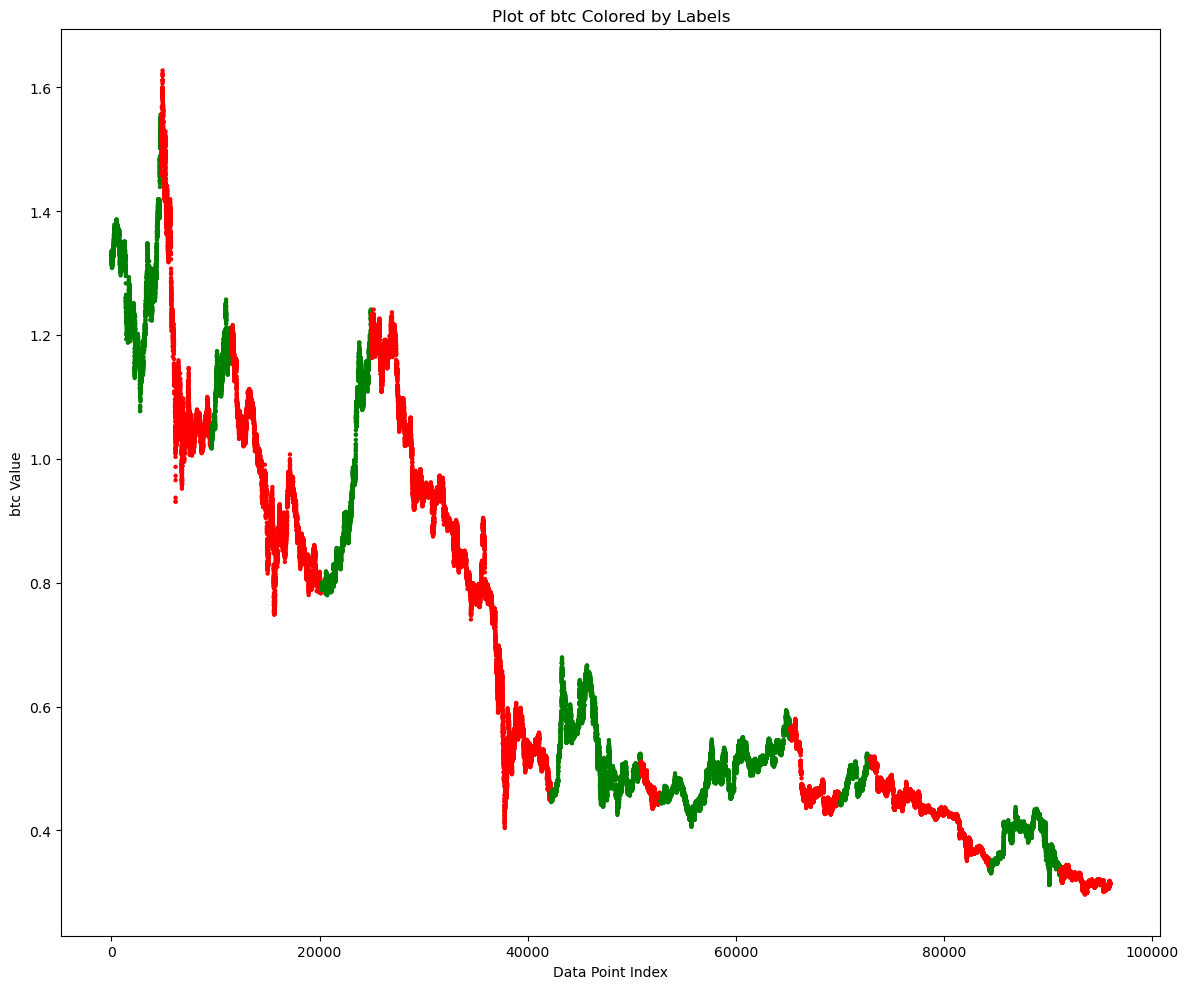

In [37]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = som_model.predict(train_matrix1)
a = som_model.refine_bmu_sequence(a, train_matrix1,lambda_jump=0.5)
initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)

# # Assuming initial_preds_rep is already defined and repeated correctly
# initial_preds_rep = np.repeat(inital_preds2.cpu(), 10*96)

resampled_data1
# Assuming eth and btc data are already extracted
btc = resampled_data1.values[:96000, 0]


# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs.scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs.set_title('Plot of btc Colored by Labels')
axs.set_xlabel('Data Point Index')
axs.set_ylabel('btc Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


In [8]:
import SIGSOM.sigsom.utils.helpers2 as helper_functions

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
# Assuming `vif_cleaned_result`, scalers, and gsomm are defined elsewhere in the code
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# # Step 3: Get predictions and quantization error
# b = som_model.predict(test_matrix)  # Replace 'gsomm.predict' with your method
# b = som_model.refine_bmu_sequence(b, test_matrix,lambda_jump=0.2)
# test_preds = np.array(b).flatten()
# initial_preds_rep = np.repeat(test_preds, 10*96)
# initial_preds_rep.shape

# # Assuming btc data is already extracted
# btc = resampled_data1.values[96000:, 0]
# output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\bitcoin.png"

# helper_functions.plot_btc_price(predictions=initial_preds_rep, btc_prices=btc, output_path=output_path, title='BTC Price Colored by Predictions')

In [9]:
predicted_bmus, arrival_costs = som_model.greedy_online_prediction(test_matrix, lambda_jump=.5)
z = som_model.refine_bmu_sequence(predicted_bmus, test_matrix, lambda_jump=0.1)
z.shape

torch.Size([92])

In [38]:
# Assuming 'som_model' is your trained SOM
predicted_bmus, arrival_costs = som_model.greedy_online_prediction(test_matrix, lambda_jump=.5)

print("Predicted BMUs:", predicted_bmus)
# print("Arrival Costs:", arrival_costs)

predicted_bmus = np.array(predicted_bmus).flatten()
predicted_bmus = np.repeat(predicted_bmus, 10*96)
predicted_bmus.shape

# Assuming btc data is already extracted
btc = resampled_data1.values[96000:, 0]


Predicted BMUs: tensor([0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
        0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])


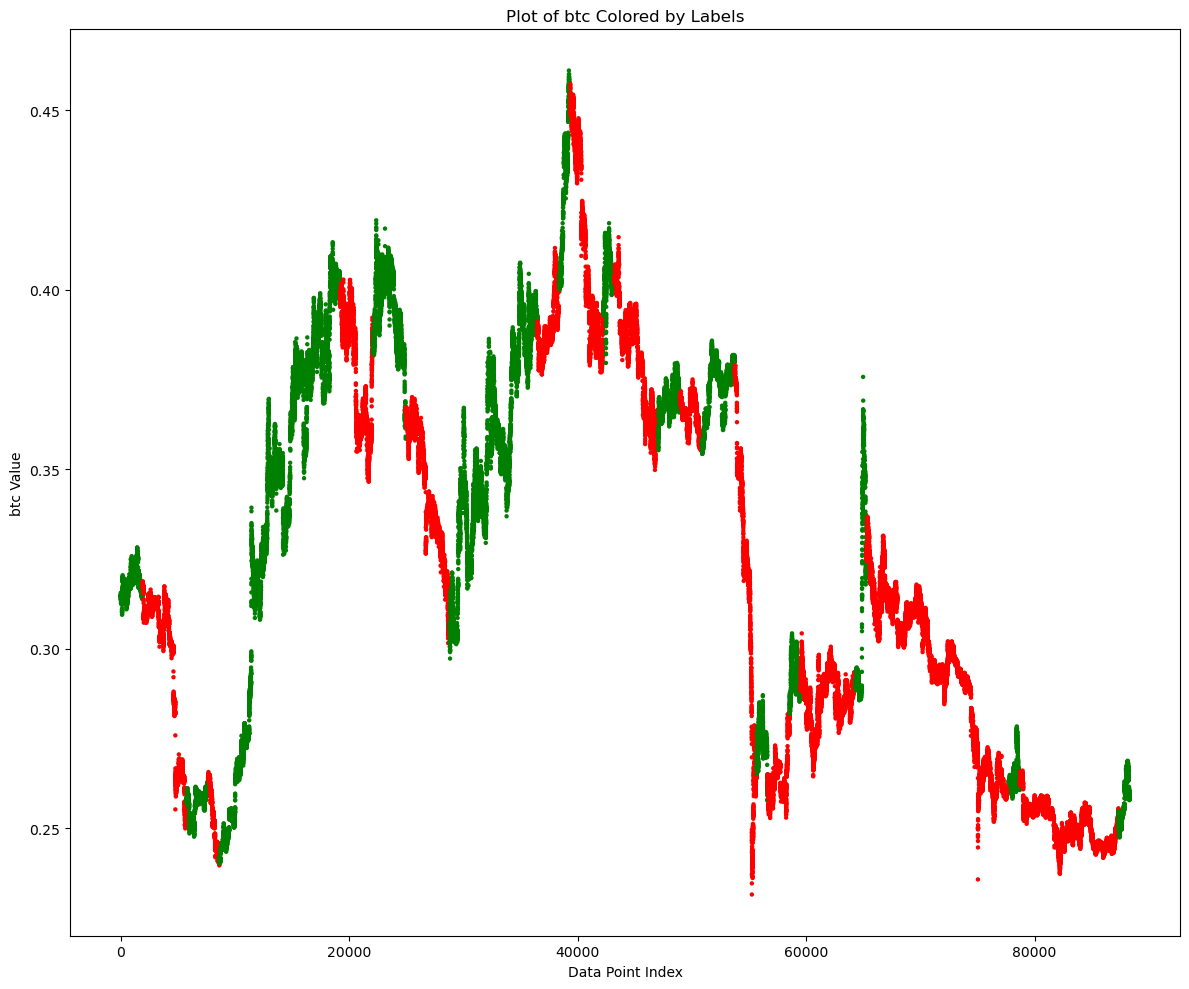

In [39]:
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs.scatter(np.arange(88320), btc[:88320],
               c=predicted_bmus, cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs.set_title('Plot of btc Colored by Labels')
axs.set_xlabel('Data Point Index')
axs.set_ylabel('btc Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [12]:
btc = resampled_data1.values[96000:, 0]


In [13]:
predicted_bmus.shape

(88320,)

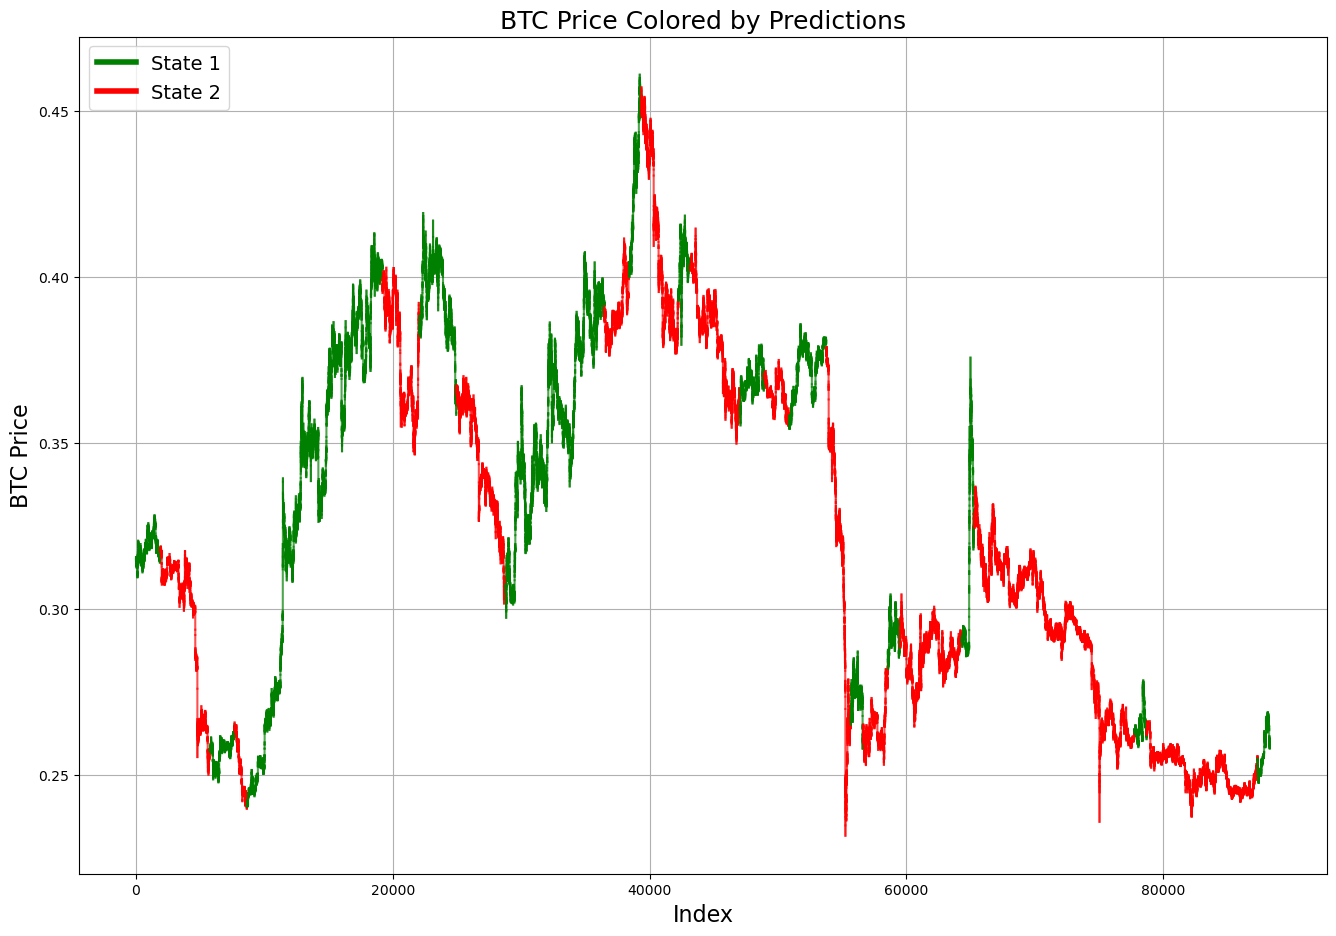

In [14]:
import SIGSOM.sigsom.utils.helpers2 as helper_functions
output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\bitcoin_jump.png"

helper_functions.plot_btc_price(predictions=predicted_bmus, btc_prices=btc, output_path=output_path, title='BTC Price Colored by Predictions')

In [15]:
test_matrix.shape

torch.Size([92, 8])

In [16]:
X = torch.rand(100, 8)  # Random input with 100 time steps
predicted_bmus, arrival_costs = som_model.greedy_online_prediction(X, lambda_jump=10000000000000)

print(predicted_bmus.shape)  # Expected: (100,)
print(arrival_costs.shape)   # Expected: (100, num_units)

torch.Size([100])
torch.Size([100, 2])


In [17]:
predicted_bmus

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1])